# 📊 Telco Customer Churn Analysis

## 🎯 Objective
The goal of this project is to predict customer churn using machine learning.

Churn refers to customers who stop using a company's service.
By predicting churn in advance, companies can identify high-risk customers and take action to improve retention.

---

## 📁 Dataset
- Source: IBM Telco Customer Churn dataset
- Type: Tabular dataset
- Target variable: `Churn` (Yes / No)

---

## 🔍 Problem Type
- Binary classification
- Goal: Predict the probability of churn

---

## 📌 EDA Goals
- Understand the data structure
- Identify missing values and anomalies
- Explore relationships between features and churn
- Define preprocessing rules that will remain consistent in later pipeline stages

In [ ]:
# 2. Import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import warnings

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

In [ ]:
# 3. Load raw data
data_path = Path("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df = pd.read_csv(data_path)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 1. Basic Data Inspection

We first inspect:
- dataset size
- column names
- data types
- summary statistics

In [ ]:
# 5. Inspect dataset shape and info
print("Shape:", df.shape)
df.info()

Shape: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 n

In [ ]:
# 6. Summary statistics of numeric variables
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
# 7. List all columns
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

### 2. Target Variable Analysis

We check the distribution of the target variable (`Churn`) to understand whether the dataset is imbalanced.

In [ ]:
# 9. Check target distribution (count)
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [ ]:
# 10. Check target distribution (ratio)
df["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

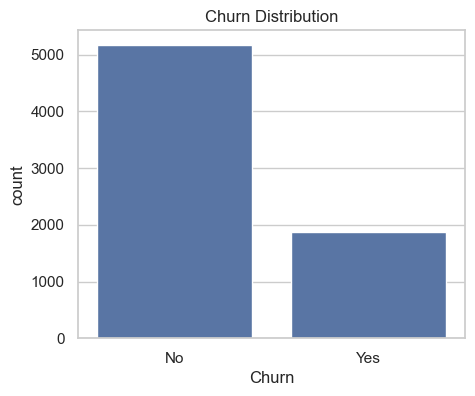

In [ ]:
# 11. Visualize churn distribution
plt.figure(figsize=(5,4))
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

### Interpretation
- The target variable is imbalanced.
- This means accuracy alone is not an appropriate evaluation metric.
- Future modeling should consider ROC-AUC, F1, Recall, and Precision.

### 3. Missing Value Check

We inspect missing values and potential hidden missing patterns, especially for columns that may contain blank strings.

In [ ]:
# 14. Checking missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### 4. Important Data Quality Issue: `TotalCharges`

In this dataset, `TotalCharges` often appears numeric, but may contain blank strings or be stored as object type.

We need to inspect and convert it properly.

In [ ]:
# 16. Inspect TotalCharges raw values
df["TotalCharges"].head(10)

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: object

In [ ]:
# 17. Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [ ]:
# 18. Checking missing after conversion
df["TotalCharges"].isnull().sum()

np.int64(11)

In [ ]:
# 19. Drop missing values
df = df.dropna().copy()

In [ ]:
# 20. Verify missing values removed
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Interpretation
- `TotalCharges` required numeric conversion before analysis.
- Invalid or blank entries were coerced to missing values and removed.
- This preprocessing rule should remain consistent in later feature engineering and pipeline implementation.

### 5. Additional Data Quality Checks

We check:
- duplicate rows
- uniqueness of customer IDs
- consistency of customer-level records

In [ ]:
# 23. Check duplicates and customerID uniqueness
print("Duplicate rows:", df.duplicated().sum())
print("Unique customer IDs:", df["customerID"].nunique())
print("Total rows:", len(df))

Duplicate rows: 0
Unique customer IDs: 7032
Total rows: 7032


### Interpretation
- Duplicate rows should ideally be zero in a customer-level dataset.
- `customerID` should uniquely identify each customer record.
- This supports treating `customerID` as an identifier rather than a predictive feature.

### 6. Feature Type Separation

Before modeling, we need to separate:
- numeric variables
- categorical variables
- identifier columns
- target variable

Important decisions:
- `customerID` should be excluded from modeling
- `SeniorCitizen` should be treated as a categorical/binary variable

In [ ]:
# 26. Separate numeric and categorical features
id_col = "customerID"
target_col = "Churn"

categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

if id_col in categorical_cols:
    categorical_cols.remove(id_col)

if target_col in categorical_cols:
    categorical_cols.remove(target_col)

if "SeniorCitizen" in numeric_cols:
    numeric_cols.remove("SeniorCitizen")

categorical_cols.append("SeniorCitizen")

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)
print("Excluded ID column:", id_col)
print("Target column:", target_col)

Numeric columns: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'SeniorCitizen']
Excluded ID column: customerID
Target column: Churn


### Interpretation
- `customerID` is an identifier and should be excluded from modeling.
- `SeniorCitizen` is numerically encoded, but conceptually it is a binary categorical feature.
- `Churn` is the target variable and should not remain in the feature list.

### 7. Target Encoding Preview

For future modeling, `Churn` will be converted into a binary target:
- Yes → 1
- No → 0

In [ ]:
# 29. Create binary target variable (Churn_binary)
df["Churn_binary"] = df["Churn"].map({"No": 0, "Yes": 1})
df[["Churn", "Churn_binary"]].head()

,Churn,Churn_binary
0,No,0
1,No,0
2,Yes,1
3,No,0
4,Yes,1


In [ ]:
# 30. Check encoded target distribution
df["Churn_binary"].value_counts()

Churn_binary
0    5163
1    1869
Name: count, dtype: int64

### Interpretation
- The encoded target confirms class imbalance.
- This supports using ROC-AUC, F1, Recall, and Precision instead of accuracy alone.

### 8. Numeric Feature Analysis

We explore how major numeric features differ by churn status.

Key numeric features:
- tenure
- MonthlyCharges
- TotalCharges

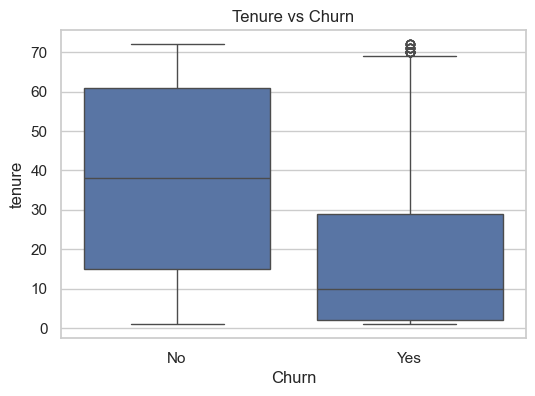

In [ ]:
# 33. Tenure vs Churn (boxplot)
plt.figure(figsize=(6, 4))
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure vs Churn")
plt.show()

In [ ]:
# 34. Tenure summary statistics by churn
df.groupby("Churn")["tenure"].agg(["mean", "median", "std", "min", "max"])

,mean,median,std,min,max
Churn,,,,,
No,37.650010,38.0,24.076940,1,72
Yes,17.979133,10.0,19.531123,1,72


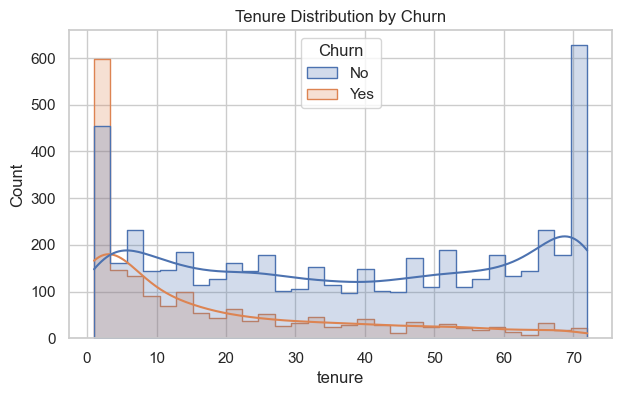

In [ ]:
# 35. Tenure distribution by churn (histogram)
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="tenure", hue="Churn", bins=30, kde=True, element="step")
plt.title("Tenure Distribution by Churn")
plt.show()

### Interpretation: tenure
- Customers who churn tend to have shorter tenure on average.
- The churned group is concentrated more heavily in lower tenure ranges.
- The apparent outliers in the boxplot should not be removed, because they are valid long-term customers rather than data errors.
- This suggests that early-stage customer retention is an important business issue.

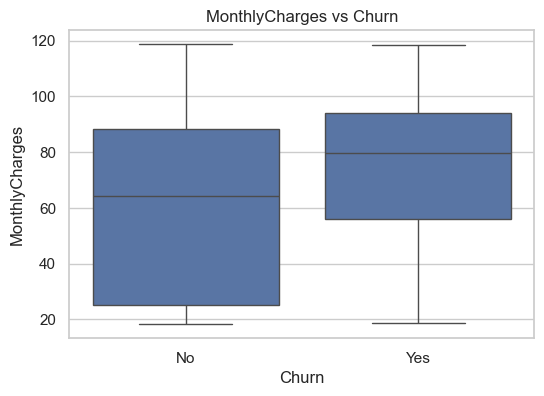

In [ ]:
# 37. MonthlyCharges vs Churn (boxplot)
plt.figure(figsize=(6, 4))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("MonthlyCharges vs Churn")
plt.show()

In [ ]:
# 38. MonthlyCharges summary statistics
df.groupby("Churn")["MonthlyCharges"].agg(["mean", "median", "std", "min", "max"])

,mean,median,std,min,max
Churn,,,,,
No,61.307408,64.45,31.094557,18.25,118.75
Yes,74.441332,79.65,24.666053,18.85,118.35


### Interpretation: MonthlyCharges
- Customers who churn tend to have higher monthly charges on average.
- This may reflect price sensitivity or lower perceived value relative to cost.

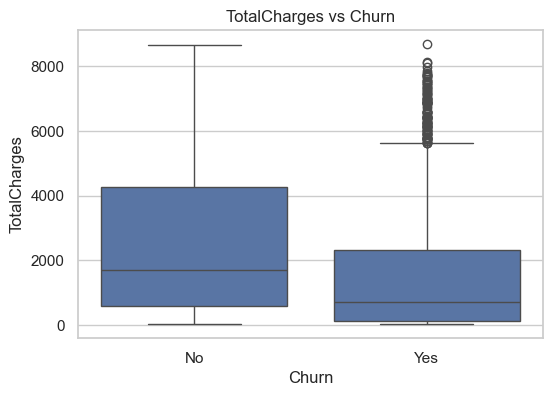

In [ ]:
# 40. TotalCharges vs Churn (boxplot)
plt.figure(figsize=(6, 4))
sns.boxplot(x="Churn", y="TotalCharges", data=df)
plt.title("TotalCharges vs Churn")
plt.show()

In [ ]:
# 41. TotalCharges summary statistics
df.groupby("Churn")["TotalCharges"].agg(["mean", "median", "std", "min", "max"])

,mean,median,std,min,max
Churn,,,,,
No,2555.344141,1683.60,2329.456984,18.80,8672.45
Yes,1531.796094,703.55,1890.822994,18.85,8684.80


### Interpretation: TotalCharges
- `TotalCharges` reflects cumulative customer spending.
- It should be interpreted together with tenure rather than in isolation.
- Since `TotalCharges` accumulates over time, it is naturally related to customer duration.

## 9. Categorical Feature Analysis

For categorical variables, count plots are useful,
but churn rate is more important than raw counts.

We therefore inspect both:
- count distribution
- churn rate by category

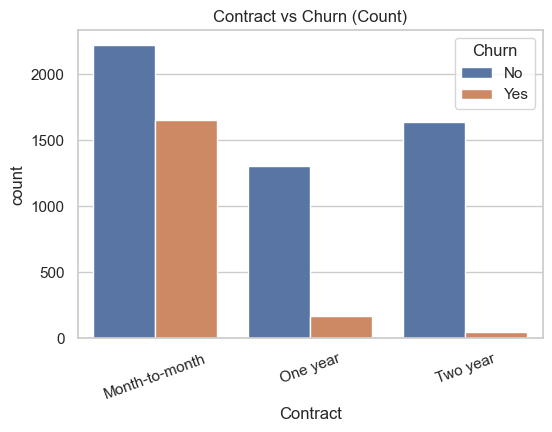

In [ ]:
# 44. Contract vs Churn (countplot)
plt.figure(figsize=(6, 4))
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Contract vs Churn (Count)")
plt.xticks(rotation=20)
plt.show()

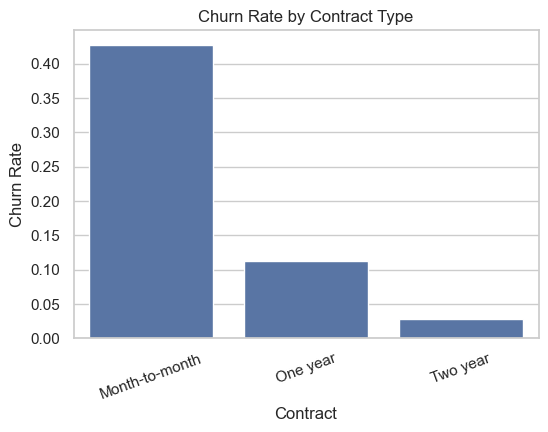

In [ ]:
# 45. Churn rate by Contract
contract_churn_rate = (
    df.groupby("Contract")["Churn_binary"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(6, 4))
sns.barplot(x=contract_churn_rate.index, y=contract_churn_rate.values)
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate")
plt.xlabel("Contract")
plt.xticks(rotation=20)
plt.show()

### Interpretation: Contract
- Month-to-month contracts show the highest churn rate.
- Longer contract commitments are associated with lower churn.
- Contract type is likely to be an important predictive feature.

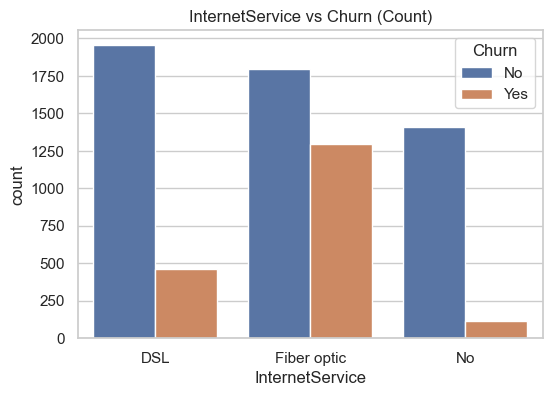

In [ ]:
# 47. InternetService vs Churn (countplot)
plt.figure(figsize=(6, 4))
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.title("InternetService vs Churn (Count)")
plt.show()

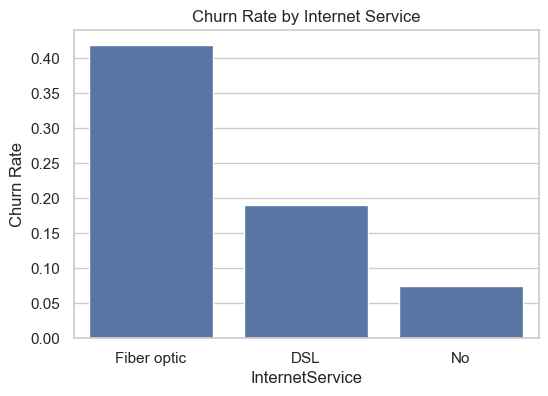

In [ ]:
# 48. Churn rate by InternetService
internet_churn_rate = (
    df.groupby("InternetService")["Churn_binary"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(6, 4))
sns.barplot(x=internet_churn_rate.index, y=internet_churn_rate.values)
plt.title("Churn Rate by Internet Service")
plt.ylabel("Churn Rate")
plt.xlabel("InternetService")
plt.show()

### Interpretation: InternetService
- Churn behavior differs by internet service type.
- This suggests service category may affect customer satisfaction and retention risk.

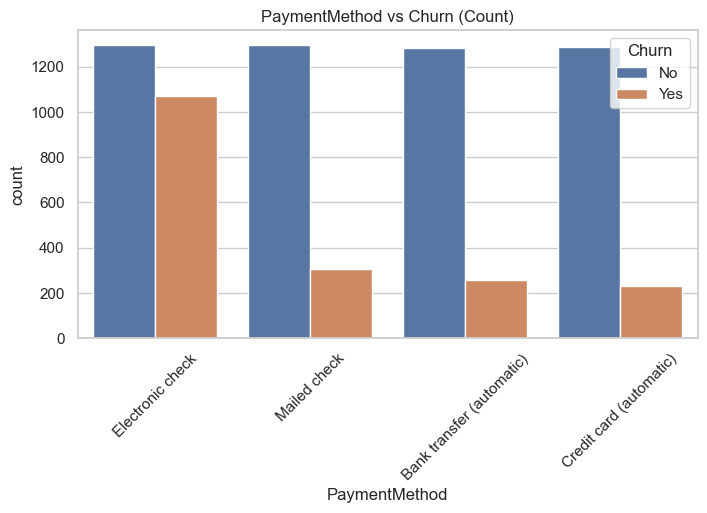

In [ ]:
# 50. PaymentMethod vs Churn (countplot)
plt.figure(figsize=(8, 4))
sns.countplot(x="PaymentMethod", hue="Churn", data=df)
plt.title("PaymentMethod vs Churn (Count)")
plt.xticks(rotation=45)
plt.show()

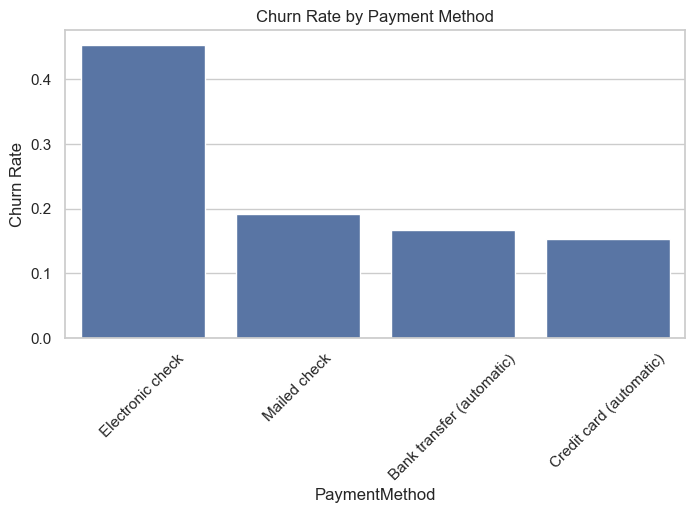

In [ ]:
# 51. Churn rate by PaymentMethod
payment_churn_rate = (
    df.groupby("PaymentMethod")["Churn_binary"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 4))
sns.barplot(x=payment_churn_rate.index, y=payment_churn_rate.values)
plt.title("Churn Rate by Payment Method")
plt.ylabel("Churn Rate")
plt.xlabel("PaymentMethod")
plt.xticks(rotation=45)
plt.show()

### Interpretation: PaymentMethod
- Payment method is associated with different churn rates.
- This may reflect behavioral or service-experience differences across payment groups.

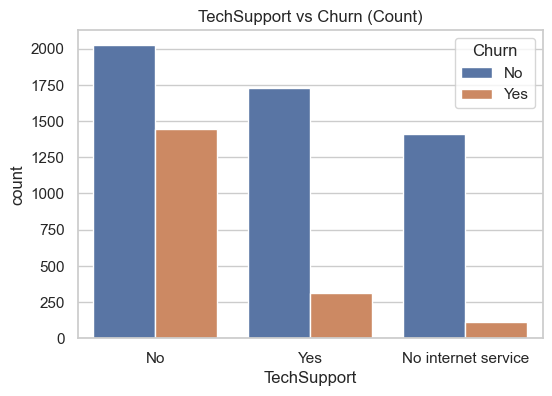

In [ ]:
# 53. TechSupport vs Churn (countplot)
plt.figure(figsize=(6, 4))
sns.countplot(x="TechSupport", hue="Churn", data=df)
plt.title("TechSupport vs Churn (Count)")
plt.show()

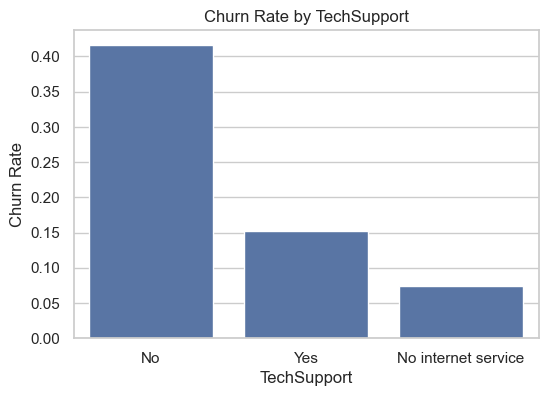

In [ ]:
# 54. Churn rate by TechSupport
techsupport_churn_rate = (
    df.groupby("TechSupport")["Churn_binary"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(6, 4))
sns.barplot(x=techsupport_churn_rate.index, y=techsupport_churn_rate.values)
plt.title("Churn Rate by TechSupport")
plt.ylabel("Churn Rate")
plt.xlabel("TechSupport")
plt.show()

### Interpretation: TechSupport
- Customers without tech support tend to churn more.
- Support-related features may provide strong retention signals.

## 10. Correlation Analysis (Numeric Only)

We inspect correlations among numeric variables to understand:
- linear relationships
- potential redundancy
- feature behavior before modeling

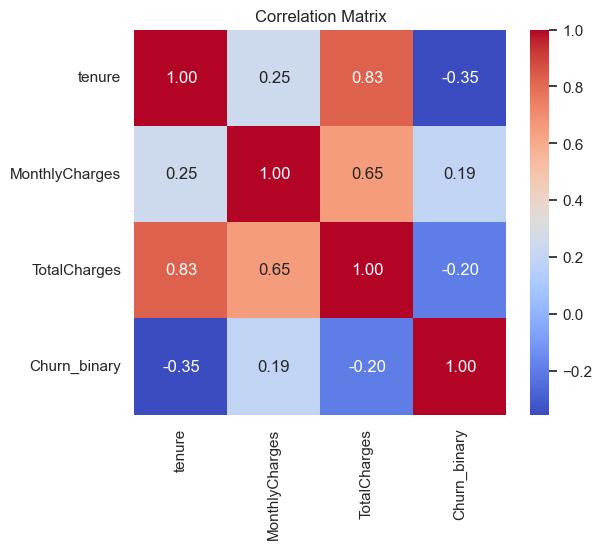

In [ ]:
# 57. Correlation analysis (numeric features + target)
corr_cols = numeric_cols + ["Churn_binary"]

plt.figure(figsize=(6, 5))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

### Interpretation
- Numeric variables help explain customer duration and spending patterns.
- Correlation with `Churn_binary` helps identify candidate predictors.
- This step is exploratory only; nonlinear effects may still exist even when linear correlation is weak.

## 📌 Key Insights

### 1. Target Distribution
- Churn is imbalanced, so accuracy alone is not sufficient.
- Future evaluation should include ROC-AUC, F1, Recall, and Precision.

### 2. Numeric Feature Patterns
- Customers with shorter tenure show a higher tendency to churn.
- Higher MonthlyCharges are associated with higher churn risk.
- TotalCharges required numeric conversion and missing-value handling.

### 3. Categorical Feature Signals
- Month-to-month contracts show higher churn tendency.
- Customers without TechSupport tend to churn more.
- InternetService type appears to be related to churn behavior.
- PaymentMethod may also be associated with churn differences.

### 4. Data Preprocessing Decisions
- `customerID` should be excluded from modeling.
- `SeniorCitizen` should be treated as a categorical/binary feature.
- `Churn` should be encoded into a binary target variable.
- `TotalCharges` should remain numeric after coercion and missing-value handling.
- Preprocessing must remain consistent between training and inference.

---

## 🚀 Next Step

Move to feature engineering:
- define the final feature set
- separate numeric and categorical preprocessing
- encode the target variable
- build a reproducible preprocessing pipeline